# Агентная SIR: длительность болезни

Сопоставим 10 и 14 дней заболевания при одинаковых остальных параметрах.

## Рабочее окружение

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

comprehensive_analysis (generic function with 2 methods)

## Два независимых расчёта

In [2]:
figures = []
for period in (10, 14)
    result = basic_experiment(
        "sir_run_basic__param/period_$(period)";
        infection_period = period,
    )
    plot!(result.fig; title = "Период болезни: $(period) дней")
    push!(figures, result.fig)
    display(last(result.df, 3))
end

Row,time,susceptible,infected,recovered,total,deaths
,Int64,Int64,Int64,Int64,Int64,Int64
1,98,0,2510,0,2510,490
2,99,0,2504,4,2508,492
3,100,0,2491,13,2504,496


Row,time,susceptible,infected,recovered,total,deaths
,Int64,Int64,Int64,Int64,Int64,Int64
1,98,0,2662,7,2669,331
2,99,0,2651,17,2668,332
3,100,0,2640,25,2665,335


## Совместный график

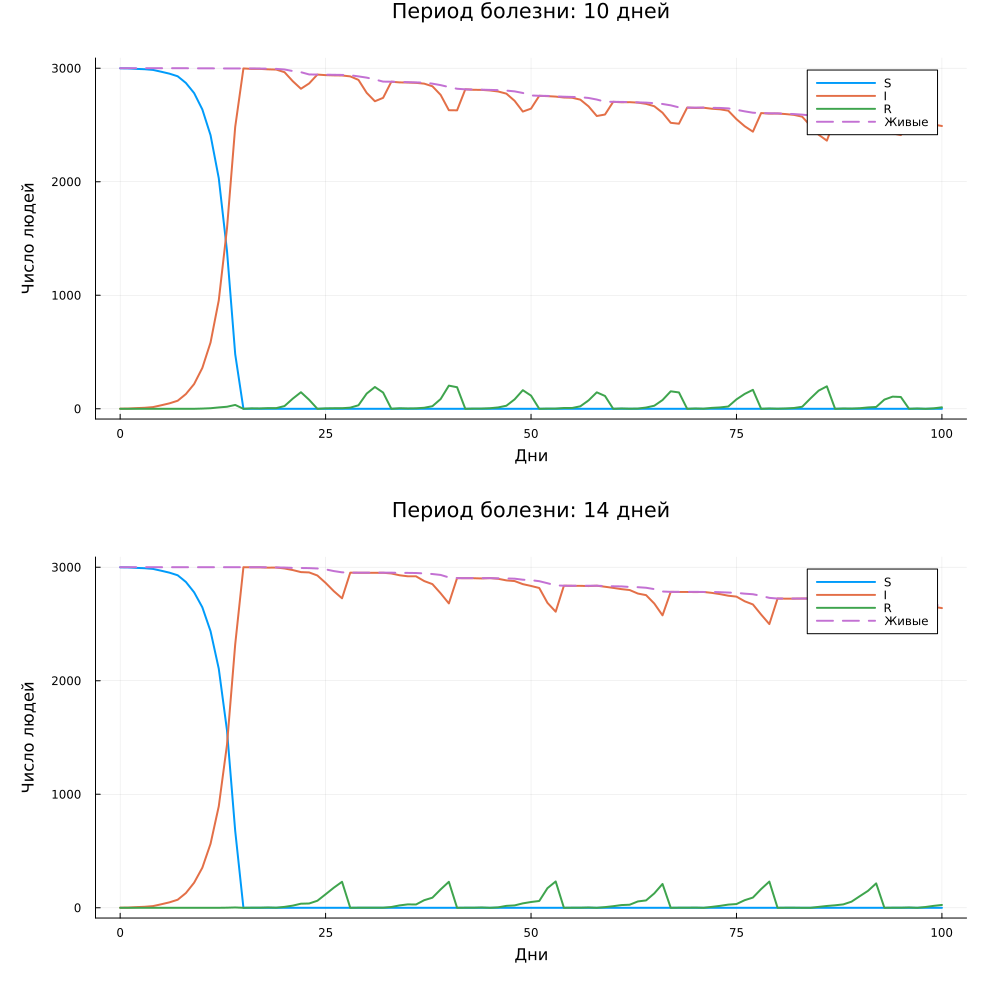

In [3]:
figure = plot(figures...; layout = (2, 1), size = (1000, 1000))
savefig(figure, imagefile("06-plot.png"))
display(figure)